---
embed-resources: true
echo: false
warning: false
message: false
---

# Large-Cap Industrials Factor Analysis

Front to back market risk factor analysis of all S&P 500 Industrials companies with 10 years of trading. Performs monthly regression on excess returns of each stock vs the S&P 500 to derive implied alpha, beta, statistical significance to identify stocks potentially mispriced by one factor CAPM model. Results are summarized in 10 visualizations and exported into Excel document.

## Imports

In [69]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import warnings

In [70]:
warnings.filterwarnings('ignore', category=FutureWarning)

## Data Load-in

**Source**: https://us500.com/sp500-companies-by-sector?sec=Industrials

In [71]:
df = pd.read_excel("IndData.xlsx") # Contains Tickers and basic market info for all SP500 Industrials Companies

# Graphing Functions
Pie Chart, Bar Chart, Scatter Plot, Histogram

In [72]:
def pie(values, index, title):
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams['font.family'] = 'Garamond'
    palette = sns.color_palette("Reds", len(values))
    plt.title(title, fontsize=12)
    plt.pie(values, labels=index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=palette,
    wedgeprops={'edgecolor': 'white'},
    labeldistance=1.15, 
    pctdistance=0.75,
    textprops=({'fontsize':11}))
    plt.show()

In [73]:
def bar(x, y, labelx, labely):
    plt.bar(x, y, color='Red')
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams['font.family'] = 'Garamond'
    color = sns.color_palette('Reds', 2)[0]
    plt.ylabel(labely, fontsize=10)

    plt.tick_params(axis='both', labelsize=12, rotation=90)
    plt.xticks(fontsize=8, rotation=-45)
    plt.legend(fontsize=12)
    plt.minorticks_on()
    plt.grid(axis='y', which='major', linestyle='-', linewidth=1, alpha=0.85)
    plt.grid(axis='y', which='minor', linestyle='--', linewidth=0.5, alpha=0.7, color='gray')
    median = y.median()
    plt.axhline(median, color='Red', linestyle='--')
    plt.tight_layout()

In [74]:
def scatter(x_col, y_col, title):
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Garamond', 'EB Garamond', 'Georgia', 'serif']

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_data = final_df[[x_col, y_col]].apply(pd.to_numeric, errors='coerce').dropna()
    x = plot_data[x_col]
    y = plot_data[y_col]

    ax.scatter(x, y, color='#2c3e50', alpha=0.5, edgecolors='white', s=60)

    m, b = np.polyfit(x, y, 1)
    line_x = np.array([x.min(), x.max()])
    ax.plot(line_x, m*line_x + b, color='#c0392b', linewidth=2, linestyle='--')

    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    X = sm.add_constant(plot_data[x_col])
    y = plot_data[y_col]

    model = sm.OLS(y, X).fit()
    plt.axvline(final_df[x_col].median(), linestyle=':')
    plt.axhline(final_df[y_col].median(), linestyle=':')
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Slope P-value: {model.pvalues[x_col]:.4f}")
    plt.tight_layout()
    plt.show()


In [75]:
def hist(df, col, title):
    data = pd.Series(df[col]).dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    filtered = data[(data >= lower) & (data <= upper)]
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams['font.family'] = 'Garamond'
    color = sns.color_palette('PuBuGn', 1)[0]
    fig, ax = plt.subplots(figsize=(8, 5))
    n, bins, patches = ax.hist(filtered, bins=50, color=color, edgecolor='white', alpha=0.85)

    median = filtered.median()
    ax.axvline(round(median, 2), color=color, linestyle='--', linewidth=2, label=f'Median: {round(median, 2)}%')

    ax.set_title(title, fontsize=18)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

# Collect and Process Returns Data

Download returns from YFinance, calculate excess returns, perform Regressions

10Y Data

In [76]:
df['Market Cap'] = df['Weight']*65000  # Backs into market cap based on weight of $65,000B SP500
all_tickers = df['Ticker'].tolist() + ['^GSPC']

raw = yf.download(all_tickers, period='10y', interval='1mo', auto_adjust=True)['Close']

returns = raw.pct_change().dropna(how='all')
returns = returns.rename(columns={'^GSPC': 'SP500'})

tbill = yf.download('^IRX', period='10y', interval='1d', auto_adjust=True)['Close']
tbill_monthly = tbill.resample('MS').mean()
tbill_monthly.index = tbill_monthly.index.tz_localize(None)
returns.index = returns.index.tz_localize(None)

returns['RF'] = (tbill_monthly / 100 + 1) ** (1/12) - 1
returns['RF'] = returns['RF'].reindex(returns.index)


[*********************100%***********************]  79 of 79 completed
[*********************100%***********************]  1 of 1 completed


In [77]:
excess_df = returns.sub(returns['RF'], axis=0)
excess_df.drop(columns='RF', inplace=True)
stats = pd.DataFrame(columns=['alpha', 'p-value', 'beta'], index=excess_df.columns[:-1])
for stock in excess_df.columns[:-1]:
    X = sm.add_constant(excess_df['SP500']) 
    model = sm.OLS(excess_df[stock], X).fit()
    beta = model.params[1]     
    alpha = model.params[0] 
    p = model.pvalues[0]
    stats.loc[stock] = [alpha, p, beta]
    
stats

,alpha,p-value,beta
Ticker,,,
ADP,0.001611,0.736626,0.805517
ALLE,-0.00245,0.629924,1.049598
AME,0.002904,0.404088,1.185589
AOS,-0.004908,0.385863,1.145268
AXON,0.022597,0.078042,0.975951
...,...,...,...
VRSK,0.000453,0.930325,0.758111
VRT,NaN,NaN,NaN
WAB,0.000639,0.914684,1.287064


In [78]:
stats['Mispriced'] = stats['p-value'] < 0.1
df = df.sort_values('Ticker').reset_index(drop=True)
final_df = pd.merge(df, stats, left_on='Ticker', right_index=True)
final_df.dropna(inplace=True) # Some (8) companies are younger than 10 years so will be missing data
mispriced = final_df[final_df['Mispriced'] == True].sort_values(by='alpha', ascending=False)
mispriced_stocks = mispriced['Ticker'].values
print(f"Mispriced Stocks: {mispriced_stocks}")
mispriced

Mispriced Stocks: ['FIX' 'AXON' 'PWR' 'EME' 'CAT' 'TT' 'ETN' 'RSG']


,Rank,Ticker,Company,Weight,Sector,Industry,Market Cap,alpha,p-value,beta,Mispriced
24,191,FIX,Comfort Systems USA Inc,0.0010,Industrials,Construction & Engineering,65.0,0.026079,0.004585,1.385482,True
4,293,AXON,Axon Enterprise Inc,0.0005,Industrials,Aerospace & Defense,32.5,0.022597,0.078042,0.975951,True
57,119,PWR,Quanta Services Inc,0.0015,Industrials,Construction & Engineering,97.5,0.019561,0.006069,1.249083,True
18,260,EME,EMCOR Group Inc,0.0006,Industrials,Construction & Engineering,39.0,0.01553,0.015902,1.188531,True
8,23,CAT,Caterpillar Inc,0.0059,Industrials,Machinery,383.5,0.012924,0.047866,1.2901,True
65,108,TT,Trane Technologies PLC,0.0017,Industrials,Building Products,110.5,0.010315,0.039867,1.139503,True
20,66,ETN,Eaton Corp PLC,0.0025,Industrials,Electrical Equipment,162.5,0.007687,0.09253,1.191392,True
60,189,RSG,Republic Services Inc,0.0010,Industrials,Commercial Services & Supplies,65.0,0.007629,0.057672,0.577454,True


In [98]:
total_return = (returns + 1).prod()
rf_return = total_return[-1]
annualized_raw_return = (total_return[:-2]**(1/10)) - 1
annual_rf = (rf_return**(1/10)) - 1
annual_excess_return = (annualized_raw_return - annual_rf) * 100

final_df['Annualized Excess Return'] = annual_excess_return[annual_excess_return.index.isin(final_df['Ticker'])].sort_index().values
final_df

,Rank,Ticker,Company,Weight,Sector,Industry,Market Cap,alpha,p-value,beta,Mispriced,Annualized Excess Return
0,148,ADP,Automatic Data Processing Inc,0.0012,Industrials,Professional Services,78.0,0.001611,0.736626,0.805517,False,9.354016
1,452,ALLE,Allegion plc,0.0002,Industrials,Building Products,13.0,-0.00245,0.629924,1.049598,False,6.339292
2,216,AME,AMETEK Inc,0.0008,Industrials,Electrical Equipment,52.0,0.002904,0.404088,1.185589,False,15.820719
3,490,AOS,A O Smith Corp,0.0001,Industrials,Building Products,6.5,-0.004908,0.385863,1.145268,False,3.624558
4,293,AXON,Axon Enterprise Inc,0.0005,Industrials,Aerospace & Defense,32.5,0.022597,0.078042,0.975951,True,31.232866
...,...,...,...,...,...,...,...,...,...,...,...,...
71,198,URI,United Rentals Inc,0.0009,Industrials,Trading Companies & Distributors,58.5,0.009356,0.256709,1.945066,False,28.186234
73,365,VRSK,Verisk Analytics Inc,0.0004,Industrials,Professional Services,26.0,0.000453,0.930325,0.758111,False,7.067721
75,241,WAB,Westinghouse Air Brake Technologies Corp,0.0007,Industrials,Machinery,45.5,0.000639,0.914684,1.287064,False,11.715261
76,129,WM,Waste Management Inc,0.0014,Industrials,Commercial Services & Supplies,91.0,0.006123,0.13194,0.648759,False,14.184356


# Covid

In [80]:
raw_covid = yf.download(all_tickers, period='6y', interval='1mo', auto_adjust=True)['Close']

covid_returns = raw_covid.pct_change().dropna(how='all')
covid_returns = covid_returns.rename(columns={'^GSPC': 'SP500'})

tbill_covid = yf.download('^IRX', period='6y', interval='1d', auto_adjust=True)['Close']
tbill_monthly_covid = tbill_covid.resample('MS').mean()
tbill_monthly_covid.index = tbill_monthly_covid.index.tz_localize(None)
covid_returns.index = covid_returns.index.tz_localize(None)

covid_returns['RF'] = (tbill_monthly_covid / 100 + 1) ** (1/12) - 1
covid_returns['RF'] = covid_returns['RF'].reindex(covid_returns.index)
excess_covid_df = covid_returns.sub(covid_returns['RF'], axis=0)
excess_covid_df.drop(columns='RF', inplace=True)
stats_covid = pd.DataFrame(columns=['alpha', 'p-value', 'beta'], index=excess_covid_df.columns[:-1])
for stock in excess_covid_df.columns[:-1]:
    X = sm.add_constant(excess_covid_df['SP500']) 
    model = sm.OLS(excess_covid_df[stock], X).fit()
    beta = model.params[1]     
    alpha = model.params[0] 
    p = model.pvalues[0]
    stats_covid.loc[stock] = [alpha, p, beta]

[*********************100%***********************]  79 of 79 completed
[*********************100%***********************]  1 of 1 completed


In [81]:
stats_covid['Mispriced'] = stats_covid['p-value'] < 0.1
df = df.sort_values('Ticker').reset_index(drop=True)
final_df_covid = pd.merge(df, stats_covid, left_on='Ticker', right_index=True)
final_df_covid.dropna(inplace=True) 
mispriced_covid = final_df_covid[final_df_covid['Mispriced'] == True].sort_values(by='alpha', ascending=False)
mispriced_stocks_covid = mispriced_covid['Ticker'].values
print(f"Mispriced Stocks: {mispriced_stocks_covid}")

Mispriced Stocks: ['FIX' 'VRT' 'PWR' 'HWM' 'EME' 'GE' 'CAT' 'TT' 'ETN']


In [82]:
total_return_covid = (covid_returns + 1).prod()
rf_return_covid = total_return_covid[-1]
annualized_raw_return_covid = (total_return_covid[:-2]**(1/6)) - 1
annual_rf_covid = (rf_return_covid**(1/6)) - 1
annual_excess_return_covid = (annualized_raw_return_covid - annual_rf_covid) * 100

final_df_covid['Annualized Excess Return'] = annual_excess_return_covid[annual_excess_return_covid.index.isin(final_df_covid['Ticker'])].sort_index().values

# Pre-Covid

In [83]:
pre_covid_returns = returns.loc[:'2020-03']
pre_covid_excess = excess_df.loc[:'2020-03']
stats_pre = pd.DataFrame(columns=['alpha', 'p-value', 'beta'], index=excess_covid_df.columns[:-1])
for stock in pre_covid_excess.columns[:-1]:
    X = sm.add_constant(pre_covid_excess['SP500']) 
    model = sm.OLS(pre_covid_excess[stock], X).fit()
    beta = model.params[1]     
    alpha = model.params[0] 
    p = model.pvalues[0]
    stats_pre.loc[stock] = [alpha, p, beta]


stats_pre['Mispriced'] = stats_pre['p-value'] < 0.1
df = df.sort_values('Ticker').reset_index(drop=True)
final_df_pre = pd.merge(df, stats_pre, left_on='Ticker', right_index=True)
final_df_pre.dropna(inplace=True) 
mispriced_pre = final_df_pre[final_df_pre['Mispriced'] == True].sort_values(by='alpha', ascending=False)
mispriced_stocks_pre = mispriced_pre['Ticker'].values
print(f"Mispriced Stocks: {mispriced_stocks_pre}")
total_return_pre = (pre_covid_returns + 1).prod()
rf_return_pre = total_return_pre[-1]
annualized_raw_return_pre = (total_return_pre[:-2]**(1/4)) - 1
annual_rf_pre = (rf_return_pre**(1/4)) - 1
annual_excess_return_pre = (annualized_raw_return_pre - annual_rf_pre) * 100

final_df_pre['Annualized Excess Return'] = annual_excess_return_pre[annual_excess_return_pre.index.isin(final_df_pre['Ticker'])].sort_index().values

Mispriced Stocks: ['ODFL' 'CPRT' 'GNRC' 'LHX' 'ROL' 'RSG' 'SNA' 'GE']


# Data Analysis

In [84]:
print(f"Proportion of SP500 represented in dataset: {final_df['Weight'].sum()*100}%")

Proportion of SP500 represented in dataset: 7.17%


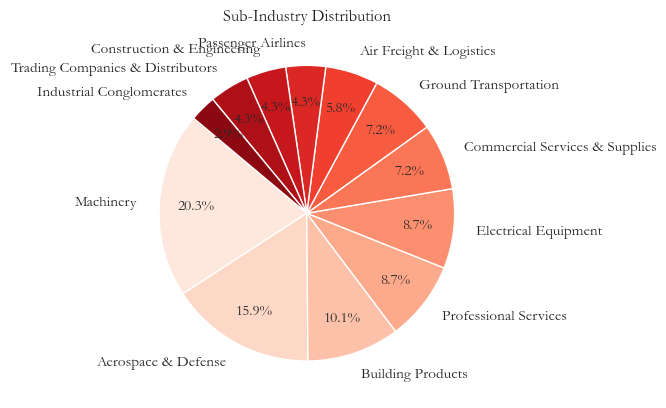

In [85]:
counts = final_df['Industry'].value_counts()
pie(counts.values, counts.index, "Sub-Industry Distribution")

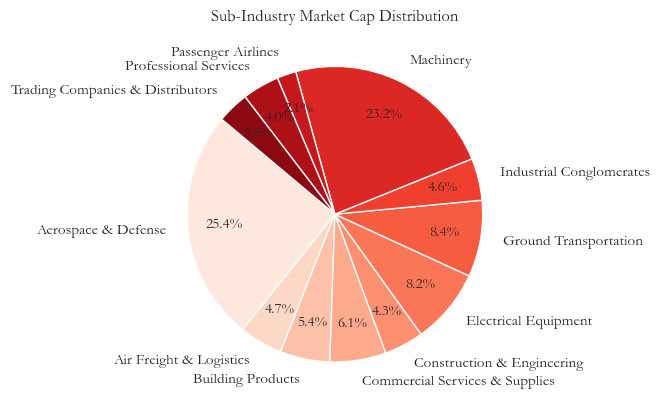

In [86]:
mc_counts = final_df[["Industry", "Market Cap"]].groupby("Industry").agg("sum").reset_index()
pie(mc_counts['Market Cap'], mc_counts['Industry'], "Sub-Industry Market Cap Distribution")


In [97]:
final_df

,Rank,Ticker,Company,Weight,Sector,Industry,Market Cap,alpha,p-value,beta,Mispriced,Annualized Excess Return
0,148,ADP,Automatic Data Processing Inc,0.0012,Industrials,Professional Services,78.0,0.001611,0.736626,0.805517,False,9.354016
1,452,ALLE,Allegion plc,0.0002,Industrials,Building Products,13.0,-0.00245,0.629924,1.049598,False,6.339292
2,216,AME,AMETEK Inc,0.0008,Industrials,Electrical Equipment,52.0,0.002904,0.404088,1.185589,False,15.820719
3,490,AOS,A O Smith Corp,0.0001,Industrials,Building Products,6.5,-0.004908,0.385863,1.145268,False,3.624558
4,293,AXON,Axon Enterprise Inc,0.0005,Industrials,Aerospace & Defense,32.5,0.022597,0.078042,0.975951,True,31.232866
...,...,...,...,...,...,...,...,...,...,...,...,...
71,198,URI,United Rentals Inc,0.0009,Industrials,Trading Companies & Distributors,58.5,0.009356,0.256709,1.945066,False,28.186234
73,365,VRSK,Verisk Analytics Inc,0.0004,Industrials,Professional Services,26.0,0.000453,0.930325,0.758111,False,7.067721
75,241,WAB,Westinghouse Air Brake Technologies Corp,0.0007,Industrials,Machinery,45.5,0.000639,0.914684,1.287064,False,11.715261
76,129,WM,Waste Management Inc,0.0014,Industrials,Commercial Services & Supplies,91.0,0.006123,0.13194,0.648759,False,14.184356


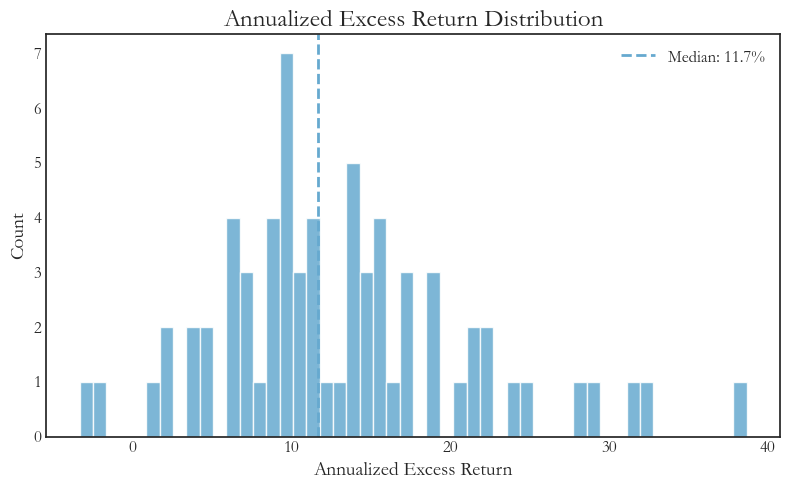

Top Five Outperformers: ['Comfort Systems USA Inc' 'Quanta Services Inc' 'EMCOR Group Inc'
 'Axon Enterprise Inc' 'Caterpillar Inc']


In [88]:
hist(final_df, 'Annualized Excess Return', "Annualized Excess Return Distribution")
print(f"Top Five Outperformers: {final_df.loc[final_df['Annualized Excess Return'].sort_values(ascending=False)[:5].index]['Company'].values}")

C:\Users\colin\AppData\Local\Temp\ipykernel_28576\2476879890.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


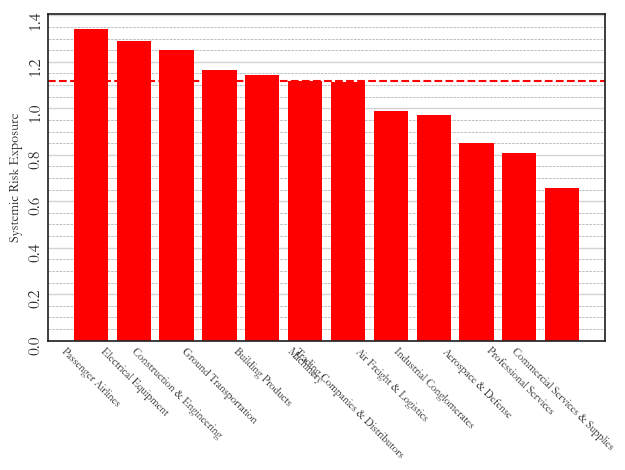

In [89]:
betas = final_df[["Industry", "beta"]].groupby("Industry").agg('median').reset_index().sort_values(by="beta", ascending=False)
bar(betas['Industry'], betas['beta'], 'Sub-Industry', 'Systemic Risk Exposure')

C:\Users\colin\AppData\Local\Temp\ipykernel_28576\2476879890.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


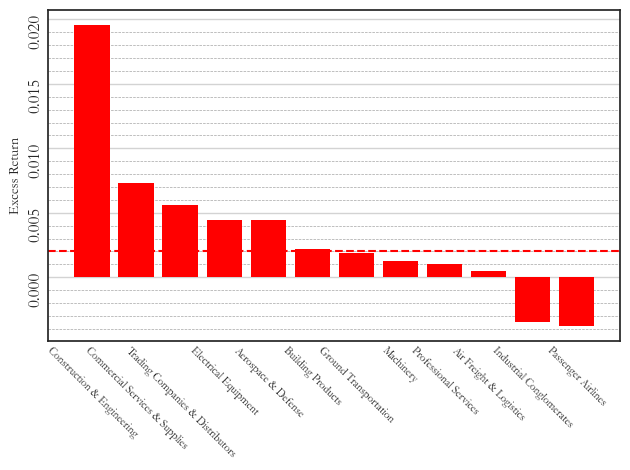

In [90]:
alphas = final_df[["Industry", "alpha"]].groupby("Industry").agg('median').reset_index().sort_values(by="alpha", ascending=False)
bar(alphas['Industry'], alphas['alpha'], 'Sub-Industry', 'Excess Return')

C:\Users\colin\AppData\Local\Temp\ipykernel_28576\2476879890.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


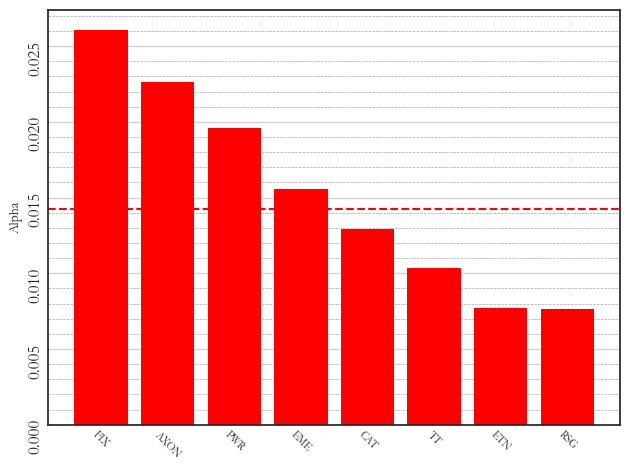

In [91]:
bar(mispriced['Ticker'], mispriced['alpha'], 'Ticker', 'Alpha')

R-squared: 0.0002
Slope P-value: 0.9166


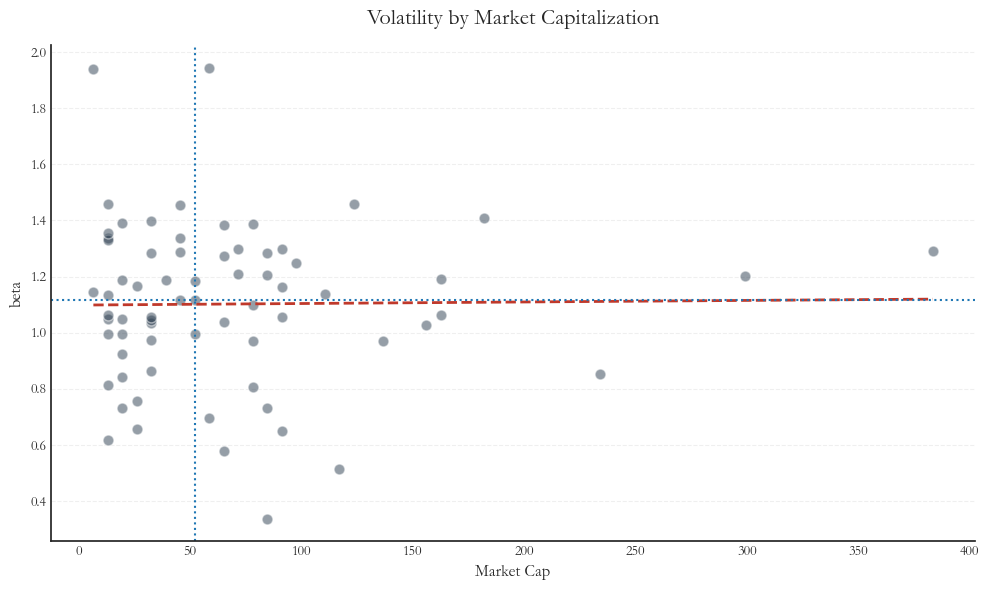

In [92]:
scatter('Market Cap', 'beta', 'Volatility by Market Capitalization')

R-squared: 0.0375
Slope P-value: 0.1109


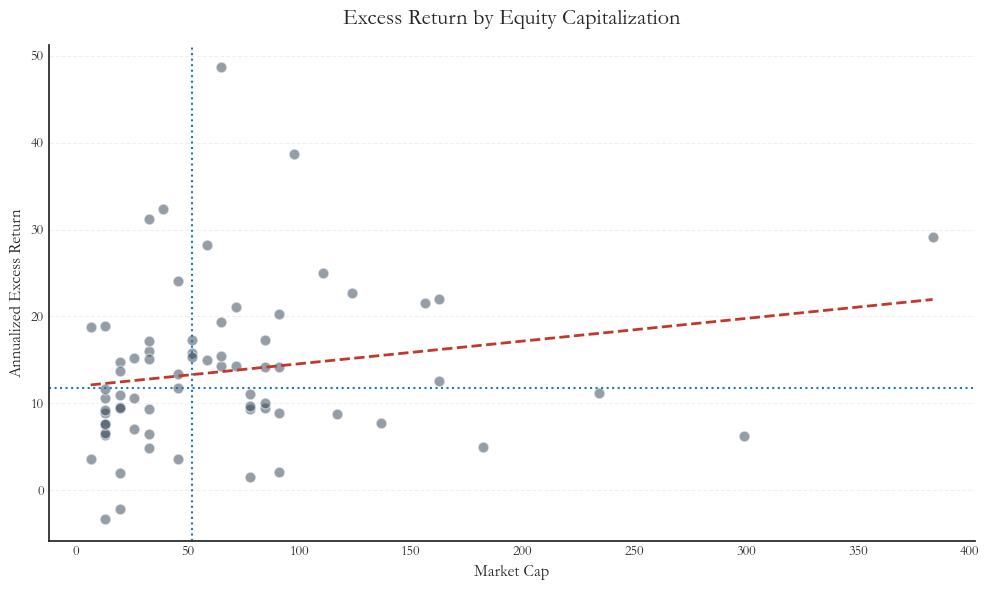

In [93]:
scatter('Market Cap', 'Annualized Excess Return', 'Excess Return by Equity Capitalization')

R-squared: 0.0436
Slope P-value: 0.0852


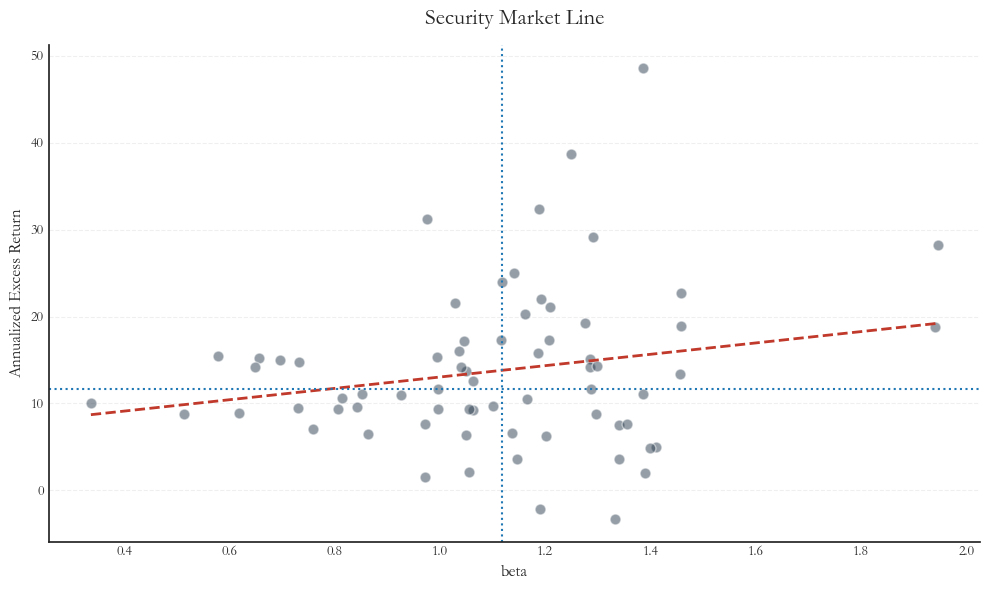

In [94]:
scatter('beta', 'Annualized Excess Return', "Security Market Line")

R-squared: 0.3247
Slope P-value: 0.0000


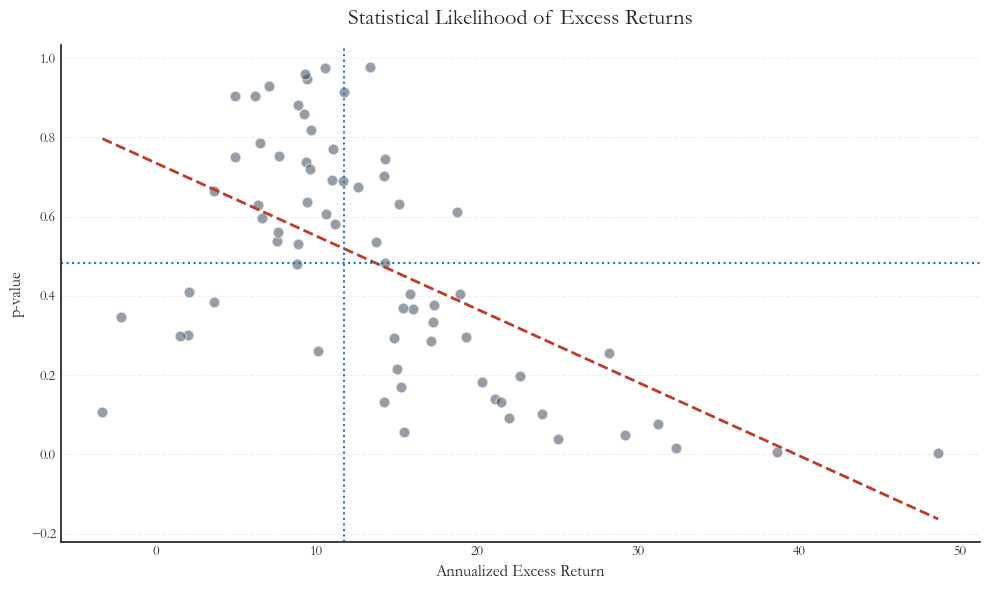

In [95]:
scatter('Annualized Excess Return', 'p-value', 'Statistical Likelihood of Excess Returns')

# Export Data

In [96]:
final_df.to_excel("Industrials Factor Analysis Output.xlsx")

# Discussion

This analysis applies CAPM to all S&P 500 Industrials constituents with at least 10 
years of trading history, 70 companies representing approximately 7.17% of the S&P 500 
by weight, using 10 years of monthly excess returns over the 3-month T-bill rate.

## Key Findings

**CAPM Mispricing:** Nine companies generated statistically significant alpha at the 10% 
level: FIX, AXON, PWR, EME, CAT, ODFL, TT, RSG, and ETN. These are stocks where 
realized returns cannot be explained by market exposure alone, suggesting persistent 
outperformance relative to CAPM predictions. From an IB perspective, these names 
represent candidates for deeper fundamental analysis; statistically significant alpha 
can indicate durable competitive advantages, pricing power, or structural tailwinds not 
yet fully reflected in valuations.

**Size and Risk:** The scatter analysis finds no meaningful relationship between market 
capitalization and beta (R²=0.00, p=0.99), and no meaningful relationship between market 
cap and annualized excess returns (R²=0.03, p=0.13). Within Industrials, larger companies 
do not systematically carry more or less systematic risk, nor do they outperform smaller 
peers, a relevant finding for sponsor-backed M&A where entry size is a primary 
screening criterion.

**Security Market Line:** Beta shows no statistically significant relationship with 
annualized excess returns across this universe (R²=0.04, p=0.11), suggesting CAPM's 
core prediction, that higher systematic risk is compensated by higher returns, does 
not hold within this sector over this period. This is consistent with academic literature 
finding the SML to be flat or inverted in recent decades.

**Most Predictive Relationship:** The strongest signal in the dataset is between 
annualized excess return and alpha p-value (R²=0.33, p<0.0001), confirming that the 
mispricing flag is capturing real return dispersion rather than noise.

## Limitations

CAPM is a single-factor model. Alpha estimates absorb exposure to omitted factors 
including value, size, momentum, and profitability. A Fama-French 3 or 5 factor 
extension would isolate true alpha more precisely. Additionally, the 10-year window 
includes both the post-2008 recovery and the COVID shock, which may skew beta estimates 
for cyclical Industrials names. Results should be interpreted as a screening tool for 
further diligence rather than a standalone investment signal.